# Fine-Tuning Unsloth — `instruction + context → thought + completion`

Notebook ini menjalankan **supervised fine-tuning (SFT) tanpa retrieval**.

Alurnya:

```text
instruction + context → model fine-tuned → thought + completion
```

Ketentuan notebook:

- Semua baris dataset dimasukkan ke training.
- Tidak ada filter pertanyaan test.
- Tidak ada train/validation split.
- Tidak ada embedding, vector database, top-k, atau proses retrieval.
- Context dibaca langsung dari field `context` atau `documents` pada dataset.
- Thought dibaca langsung dari field `thought` atau `thought_process`.
- Jawaban akhir dibaca dari field `completion`.
- Saat inference, context dapat diberikan langsung ke fungsi `generate_response()`.

> Karena seluruh data masuk training, pengujian pada pertanyaan yang sama mengukur kemampuan pembelajaran/memorisasi data training, bukan generalisasi ke data baru.


## 1. Instalasi dependensi


In [1]:
# Jalankan hanya jika environment belum memiliki dependensi berikut.
# Setelah instalasi, restart kernel lalu jalankan notebook dari awal.

# %pip install -U unsloth unsloth_zoo
# %pip install -U transformers trl peft accelerate bitsandbytes datasets
# %pip install -U pandas matplotlib


## 2. Konfigurasi


In [2]:
from pathlib import Path
import os


def first_existing(candidates, kind="file"):
    for candidate in candidates:
        path = Path(candidate).expanduser()
        if kind == "file" and path.is_file():
            return path.resolve()
        if kind == "dir" and path.is_dir():
            return path.resolve()
    return None


# Dataset boleh berupa JSONL atau JSON array.
DATA_PATH = (
    Path(os.environ["SFT_DATA_PATH"]).expanduser().resolve()
    if "SFT_DATA_PATH" in os.environ
    else first_existing([
        "/workspace/data/dataset/raft_dataset_finalv3.jsonl",
        "/workspace/data/raft_dataset_finalv3.jsonl",
        "../data/dataset/raft_dataset_finalv3.jsonl",
        "./raft_dataset_finalv3.jsonl",
        "/mnt/data/raft_dataset_finalv3.jsonl",
    ])
)

local_model = first_existing([
    "/workspace/model/Meta-Llama-3.1-8B-Instruct",
    "../model/Meta-Llama-3.1-8B-Instruct",
    "./Meta-Llama-3.1-8B-Instruct",
], kind="dir")

MODEL_NAME = os.environ.get(
    "SFT_MODEL_NAME",
    str(local_model) if local_model else "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
)

OUTPUT_ROOT = Path(os.environ.get(
    "SFT_OUTPUT_DIR",
    "/workspace/model/sft_instruction_context_thought_completion"
    if Path("/workspace/model").is_dir()
    else "./sft_instruction_context_thought_completion",
)).expanduser().resolve()

ADAPTER_DIR = OUTPUT_ROOT / "lora_adapter"
MERGED_DIR = OUTPUT_ROOT / "merged_16bit"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"

# Model dan LoRA
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = True
LORA_R = 16
LORA_ALPHA = 32
SEED = 3407

# Training: SEMUA data masuk training.
NUM_TRAIN_EPOCHS = 5
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01

# Penyimpanan merged model membutuhkan ruang disk/RAM besar.
SAVE_MERGED_16BIT = False

# Uji cepat setelah training.
MAX_NEW_TOKENS = 1024

assert DATA_PATH is not None and DATA_PATH.is_file(), (
    "Dataset tidak ditemukan. Atur environment variable SFT_DATA_PATH "
    "atau ubah DATA_PATH pada cell konfigurasi."
)

for directory in [OUTPUT_ROOT, ADAPTER_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset    :", DATA_PATH)
print("Base model :", MODEL_NAME)
print("Output     :", OUTPUT_ROOT)
print("Semua data akan dimasukkan ke training, termasuk context dan thought.")


Dataset    : /workspace/data/dataset/raft_dataset_finalv3.jsonl
Base model : /workspace/model/Meta-Llama-3.1-8B-Instruct
Output     : /workspace/model/sft_instruction_context_thought_completion
Semua data akan dimasukkan ke training, termasuk context dan thought.


## 3. Import, seed, dan pemeriksaan GPU


In [3]:
import gc
import inspect
import json
import random

import numpy as np
import pandas as pd
import torch
import transformers
import trl
from datasets import Dataset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("TRL         :", trl.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    for index in range(torch.cuda.device_count()):
        properties = torch.cuda.get_device_properties(index)
        print(
            f"GPU {index}: {torch.cuda.get_device_name(index)} | "
            f"{properties.total_memory / 1024**3:.2f} GB"
        )

assert torch.cuda.is_available(), (
    "Fine-tuning model 8B dengan konfigurasi ini membutuhkan GPU CUDA."
)


/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.11.0+cu128
Transformers: 5.5.0
TRL         : 0.24.0
CUDA        : True
GPU 0: NVIDIA B200 | 178.36 GB


## 4. Memuat `instruction`, `context`, `thought`, dan `completion`


In [4]:
def load_json_or_jsonl(path):
    path = Path(path)

    if path.suffix.lower() == ".jsonl":
        rows = []
        with path.open("r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                if not line.strip():
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as error:
                    raise ValueError(
                        f"JSONL rusak pada baris {line_number}: {error}"
                    ) from error
        return rows

    with path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    if isinstance(data, list):
        return data
    if isinstance(data, dict) and isinstance(data.get("data"), list):
        return data["data"]

    raise ValueError(
        "File JSON harus berupa array/list atau object dengan field 'data' berupa list."
    )


def clean_text(value):
    if value is None:
        return ""
    if isinstance(value, str):
        return value.strip()
    return str(value).strip()


def format_context(row):
    """Ambil context dari field `context`, atau fallback ke `documents`."""
    context = row.get("context")

    if isinstance(context, str):
        return context.strip()

    if isinstance(context, list):
        parts = [clean_text(item) for item in context if clean_text(item)]
        return "\n\n".join(
            f"[Context {index}]\n{text}"
            for index, text in enumerate(parts, start=1)
        )

    documents = row.get("documents")
    if isinstance(documents, str):
        return documents.strip()

    if isinstance(documents, list):
        parts = [clean_text(item) for item in documents if clean_text(item)]
        return "\n\n".join(
            f"[Dokumen {index}]\n{text}"
            for index, text in enumerate(parts, start=1)
        )

    return ""


def format_thought_process(value):
    """Ubah `thought`/`thought_process` menjadi teks training yang rapi."""
    if isinstance(value, str):
        return value.strip()

    if not isinstance(value, dict):
        return ""

    sections = []

    document_analysis = value.get("document_analysis")
    if isinstance(document_analysis, list) and document_analysis:
        analyses = []
        for item in document_analysis:
            if not isinstance(item, dict):
                continue
            document_number = item.get("document", "?")
            analysis = clean_text(item.get("analysis"))
            if analysis:
                analyses.append(f"- Dokumen {document_number}: {analysis}")
        if analyses:
            sections.append("Analisis dokumen:\n" + "\n".join(analyses))

    summary = clean_text(value.get("summary"))
    if summary:
        sections.append("Ringkasan analisis:\n" + summary)

    # Menjaga kompatibilitas jika struktur thought_process berbeda.
    known_keys = {"document_analysis", "summary"}
    extra = {
        key: val for key, val in value.items()
        if key not in known_keys and val not in (None, "", [], {})
    }
    if extra:
        sections.append(
            "Informasi analisis tambahan:\n"
            + json.dumps(extra, ensure_ascii=False, indent=2)
        )

    return "\n\n".join(sections).strip()


def extract_thought(row):
    thought = row.get("thought")
    if thought not in (None, "", [], {}):
        return format_thought_process(thought)
    return format_thought_process(row.get("thought_process"))


raw_rows = load_json_or_jsonl(DATA_PATH)
assert raw_rows, "Dataset kosong."

training_rows = []
invalid_rows = []
warning_rows = []

for index, row in enumerate(raw_rows):
    if not isinstance(row, dict):
        invalid_rows.append((index, "baris bukan object/dict"))
        continue

    instruction = clean_text(row.get("instruction"))
    context = format_context(row)
    thought = extract_thought(row)
    completion = clean_text(row.get("completion"))

    if not instruction or not completion:
        invalid_rows.append((index, "instruction atau completion kosong"))
        continue

    if not context:
        warning_rows.append((index, "context/documents kosong"))
    if not thought:
        warning_rows.append((index, "thought/thought_process kosong"))

    # Semua baris valid tetap digunakan. Context/thought kosong diberi fallback.
    training_rows.append({
        "instruction": instruction,
        "context": context or "Tidak ada context tambahan.",
        "thought": thought or "Jawab secara langsung berdasarkan pengetahuan yang telah dipelajari.",
        "completion": completion,
    })

print("Baris mentah         :", len(raw_rows))
print("Baris valid training :", len(training_rows))
print("Baris tidak valid    :", len(invalid_rows))
print("Peringatan field kosong:", len(warning_rows))

if invalid_rows:
    print("Contoh baris tidak valid:", invalid_rows[:10])
if warning_rows:
    print("Contoh peringatan:", warning_rows[:10])

assert training_rows, "Tidak ada data training yang valid."

audit_df = pd.DataFrame(training_rows)
print("Instruction unik     :", audit_df["instruction"].nunique())
print("Pasangan unik        :", audit_df.drop_duplicates().shape[0])
print("Duplikat tetap dilatih:", len(audit_df) - audit_df.drop_duplicates().shape[0])
print("Context non-kosong   :", int((audit_df["context"] != "Tidak ada context tambahan.").sum()))
print("Thought non-kosong   :", int((audit_df["thought"] != "Jawab secara langsung berdasarkan pengetahuan yang telah dipelajari.").sum()))

display(audit_df[["instruction", "context", "thought", "completion"]].head(3))


Baris mentah         : 403
Baris valid training : 403
Baris tidak valid    : 0
Peringatan field kosong: 0
Instruction unik     : 400
Pasangan unik        : 403
Duplikat tetap dilatih: 0
Context non-kosong   : 403
Thought non-kosong   : 403


,instruction,context,thought,completion
0,Apa sih arti pemerintahan desa itu ?,[Dokumen 1]\n[dokumen: Peraturan Desa Biru No....,Analisis dokumen:\n- Dokumen 1: Dokumen ini re...,Pemerintahan desa adalah penyelenggaraan urusa...
1,Sebutkan semua unsur masyarakat yang terdiri d...,[Dokumen 1]\n[dokumen: Peraturan Desa Majasetr...,Analisis dokumen:\n- Dokumen 1: Dokumen ini re...,Unsur masyarakat yang terdiri dari tokoh dan p...
2,Apa yang dimaksud dengan badan permusyawaratan...,[Dokumen 1]\n[dokumen: Peraturan Desa Biru No....,Analisis dokumen:\n- Dokumen 1: Dokumen ini sa...,Badan permusyawaratan desa (BPD) menurut Perat...


## 5. Memuat base model dan memasang LoRA

Notebook menggunakan QLoRA 4-bit agar kebutuhan VRAM lebih rendah. Semua modul proyeksi utama diberi adapter LoRA.


In [5]:
from unsloth import FastLanguageModel, is_bfloat16_supported

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

print("Model dan LoRA siap.")


/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   1%|          | 2/291 [00:00<00:47,  6.03it/s]/workspace/.venv/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 291/291 [00:02<00:00, 100.81it/s]
Unsloth: Will load /workspace/model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


/workspace/model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model dan LoRA siap.


## 6. Membentuk dataset SFT

Format training dan inference dibuat sama:

```text
System: aturan penggunaan context dan format output
User:
  ### Instruction
  ...

  ### Context
  ...

Assistant:
  ### Thought
  ...

  ### Answer
  ...
```

`thought` dan `completion` sama-sama menjadi target training. Tidak ada retrieval; context berasal langsung dari dataset atau diberikan langsung saat inference.


In [6]:
SYSTEM_PROMPT = (
    "Anda adalah asisten AI yang menjawab pertanyaan tentang pemerintahan "
    "dan peraturan desa. Gunakan context yang diberikan sebagai dasar utama. "
    "Tulis analisis singkat dan relevan pada bagian '### Thought', lalu tulis "
    "jawaban final yang jelas pada bagian '### Answer'. Jangan mengarang fakta "
    "yang tidak didukung context."
)


def build_user_content(instruction, context):
    return (
        "### Instruction\n"
        f"{instruction.strip()}\n\n"
        "### Context\n"
        f"{context.strip()}"
    )


def build_assistant_content(thought, completion):
    return (
        "### Thought\n"
        f"{thought.strip()}\n\n"
        "### Answer\n"
        f"{completion.strip()}"
    )


def make_sft_example(row):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": build_user_content(
                    row["instruction"],
                    row["context"],
                ),
            },
        ],
        "completion": [
            {
                "role": "assistant",
                "content": build_assistant_content(
                    row["thought"],
                    row["completion"],
                ),
            },
        ],
    }


# Semua baris valid langsung masuk training. Tidak ada split dan filter test.
train_examples = [make_sft_example(row) for row in training_rows]
train_dataset = Dataset.from_list(train_examples)

print("Jumlah data training:", len(train_dataset))
print("Tidak ada validation split.")
print("Tidak ada data test yang dikeluarkan.")

print("\nContoh prompt user:")
print(train_dataset[0]["prompt"][-1]["content"])
print("\nContoh target assistant:")
print(train_dataset[0]["completion"][0]["content"])


Jumlah data training: 403
Tidak ada validation split.
Tidak ada data test yang dikeluarkan.

Contoh prompt user:
### Instruction
Apa sih arti pemerintahan desa itu ?

### Context
[Dokumen 1]
[dokumen: Peraturan Desa Biru No. 10 Tahun 2016 - Pemberdayaan Perempuan Dan Perlindungan Anak] [desa: biru] [kabupaten: bandung] [nomor: 10/2016]

pasal 1

2. pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara republik indonesia.

[Dokumen 2]
[dokumen: Peraturan Desa Cigentur Kecamatan Paseh Kabupaten Bandung No. 8 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cigentur Kecamatan Paseh Kabupaten Bandung] [desa: cigentur kecamatan paseh kabupaten bandung] [kabupaten: bandung] [nomor: 8/2018]

pasal 1

5. pemerintahan desa adalah penyelenggaraan urusan pemerintahan o

## 7. Audit panjang token


In [7]:
def example_token_length(example):
    messages = example["prompt"] + example["completion"]
    token_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
    )
    return len(token_ids)


lengths = [example_token_length(example) for example in train_dataset]
length_series = pd.Series(lengths, name="token_length")

summary = pd.DataFrame({
    "count": [len(length_series)],
    "minimum": [int(length_series.min())],
    "median": [float(length_series.median())],
    "p95": [float(length_series.quantile(0.95))],
    "maximum": [int(length_series.max())],
    "melebihi_max_seq_length": [int((length_series > MAX_SEQ_LENGTH).sum())],
})

display(summary)

if (length_series > MAX_SEQ_LENGTH).any():
    print(
        "PERINGATAN: ada contoh yang melebihi MAX_SEQ_LENGTH dan akan terpotong. "
        "Naikkan MAX_SEQ_LENGTH apabila VRAM mencukupi."
    )


,count,minimum,median,p95,maximum,melebihi_max_seq_length
0,403,416,1459.0,2046.9,2525,0


## 8. Konfigurasi `SFTTrainer`


In [8]:
from trl import SFTConfig, SFTTrainer


def accepted_parameters(callable_object):
    try:
        return set(inspect.signature(callable_object).parameters)
    except (TypeError, ValueError):
        return set()


sft_parameters = accepted_parameters(SFTConfig.__init__)

config_kwargs = {
    "output_dir": str(CHECKPOINT_DIR),
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "optim": "adamw_8bit",
    "lr_scheduler_type": "linear",
    "logging_steps": 5,
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "report_to": "none",
    "seed": SEED,
    "data_seed": SEED,
    "fp16": not is_bfloat16_supported(),
    "bf16": is_bfloat16_supported(),
    "packing": False,
    # Untuk dataset prompt-completion, loss difokuskan pada completion.
    "completion_only_loss": True,
    "dataset_num_proc": 1,
}

if "max_length" in sft_parameters:
    config_kwargs["max_length"] = MAX_SEQ_LENGTH
elif "max_seq_length" in sft_parameters:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

config_kwargs = {
    key: value
    for key, value in config_kwargs.items()
    if key in sft_parameters
}

sft_config = SFTConfig(**config_kwargs)
trainer_parameters = accepted_parameters(SFTTrainer.__init__)

trainer_kwargs = {
    "model": model,
    "args": sft_config,
    "train_dataset": train_dataset,
}

if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = tokenizer

# Dukungan untuk TRL versi lama.
if (
    "max_seq_length" in trainer_parameters
    and "max_length" not in config_kwargs
    and "max_seq_length" not in config_kwargs
):
    trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

trainer = SFTTrainer(**trainer_kwargs)

print(sft_config)
print("Jumlah contoh yang akan dilatih:", len(trainer.train_dataset))


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 403/403 [00:01<00:00, 202.48 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
UnslothSFTConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=True,
chat_template_path=None,
completion_only_loss=True,
data_seed=3407,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=1,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_

## 9. Menjalankan fine-tuning


In [9]:
print("Memulai fine-tuning pada seluruh dataset...")
trainer_stats = trainer.train()
print("Fine-tuning selesai.")
print(trainer_stats)

trainer.save_state()

with (OUTPUT_ROOT / "train_log_history.json").open("w", encoding="utf-8") as file:
    json.dump(trainer.state.log_history, file, ensure_ascii=False, indent=2)

with (OUTPUT_ROOT / "train_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(trainer_stats.metrics, file, ensure_ascii=False, indent=2)

print("Output training:", OUTPUT_ROOT)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Memulai fine-tuning pada seluruh dataset...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 403 | Num Epochs = 5 | Total steps = 130
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
5,0.562834
10,0.433457
15,0.339053
20,0.315559
25,0.299588
30,0.296955
35,0.255846
40,0.258226
45,0.250399
50,0.226833


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/checkpoints/checkpoint-26/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/checkpoints/checkpoint-52/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/checkpoints/checkpoint-78/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/checkpoints/checkpoint-104/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/checkpoints/checkpoint-130/tokenizer_config.json.


Fine-tuning selesai.
TrainOutput(global_step=130, training_loss=0.23186602867566622, metrics={'train_runtime': 1641.0469, 'train_samples_per_second': 1.228, 'train_steps_per_second': 0.079, 'total_flos': 1.3481981074219008e+17, 'train_loss': 0.23186602867566622, 'epoch': 5.0})
Output training: /workspace/model/sft_instruction_context_thought_completion


## 10. Grafik training loss


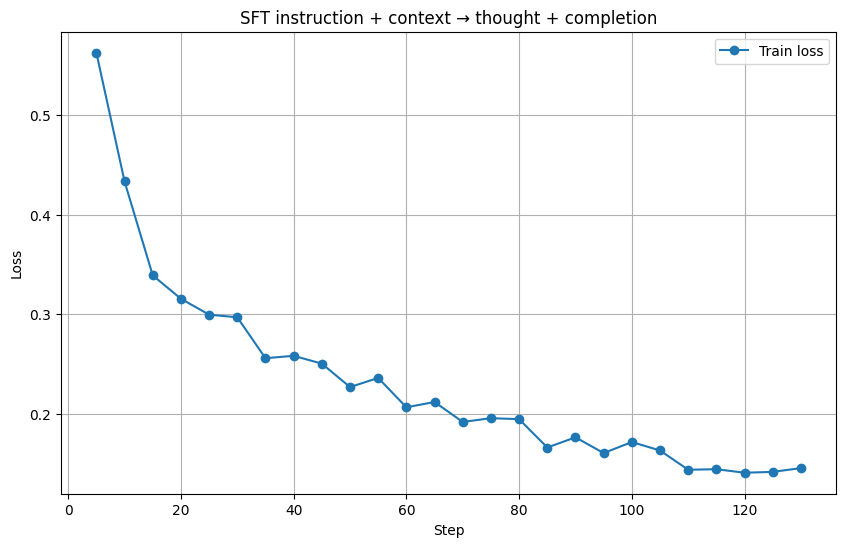

In [11]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [
    (record.get("step"), record["loss"])
    for record in history
    if "loss" in record and "eval_loss" not in record
]

plt.figure(figsize=(10, 6))
if train_points:
    plt.plot(
        [point[0] for point in train_points],
        [point[1] for point in train_points],
        marker="o",
        label="Train loss",
    )
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SFT instruction + context → thought + completion")
plt.grid(True)
plt.legend()
plt.show()


## 11. Menyimpan adapter dan merged model


In [12]:
model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print("LoRA adapter disimpan di:", ADAPTER_DIR)

if SAVE_MERGED_16BIT:
    model.save_pretrained_merged(
        str(MERGED_DIR),
        tokenizer,
        save_method="merged_16bit",
    )
    print("Merged model 16-bit disimpan di:", MERGED_DIR)
else:
    print(
        "Merged model tidak dibuat karena SAVE_MERGED_16BIT=False. "
        "Ubah menjadi True lalu jalankan ulang cell ini bila API membutuhkan merged model."
    )


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_context_thought_completion/lora_adapter/tokenizer_config.json.


LoRA adapter disimpan di: /workspace/model/sft_instruction_context_thought_completion/lora_adapter
Merged model tidak dibuat karena SAVE_MERGED_16BIT=False. Ubah menjadi True lalu jalankan ulang cell ini bila API membutuhkan merged model.


## 12. Fungsi inference tanpa retrieval

Fungsi menerima `question` dan `context` secara langsung. Context **tidak dicari** dari vector database.

- `generate_response()` mengembalikan thought dan answer.
- `generate_answer()` hanya mengembalikan answer final.
- Jika context tidak diberikan, digunakan teks fallback. Ini cocok untuk menguji memorisasi, tetapi format yang paling konsisten dengan training adalah memberikan context.


In [13]:
FastLanguageModel.for_inference(model)


def parse_model_response(text):
    text = str(text).strip()
    thought_marker = "### Thought"
    answer_marker = "### Answer"

    thought = ""
    answer = text

    if answer_marker in text:
        before_answer, answer = text.split(answer_marker, 1)
        answer = answer.lstrip(" :\n").strip()

        if thought_marker in before_answer:
            thought = before_answer.split(thought_marker, 1)[1]
            thought = thought.lstrip(" :\n").strip()
    elif thought_marker in text:
        thought = text.split(thought_marker, 1)[1].lstrip(" :\n").strip()
        answer = ""

    return {
        "thought": thought,
        "answer": answer,
        "raw_output": text,
    }


def generate_response(
    question,
    context=None,
    max_new_tokens=MAX_NEW_TOKENS,
):
    question = str(question).strip()
    if not question:
        raise ValueError("Pertanyaan tidak boleh kosong.")

    if isinstance(context, list):
        context = "\n\n".join(
            f"[Dokumen {index}]\n{clean_text(item)}"
            for index, item in enumerate(context, start=1)
            if clean_text(item)
        )
    else:
        context = clean_text(context)

    context = context or "Tidak ada context tambahan."

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": build_user_content(question, context),
        },
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated_tokens = outputs[0, inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    return parse_model_response(generated_text)


def generate_answer(question, context=None, max_new_tokens=MAX_NEW_TOKENS):
    result = generate_response(
        question=question,
        context=context,
        max_new_tokens=max_new_tokens,
    )
    return result["answer"] or result["raw_output"]


print("Fungsi generate_response dan generate_answer siap.")


Fungsi generate_response dan generate_answer siap.


## 13. Uji satu data lengkap dari dataset


In [14]:
# Mengambil contoh pertama dari dataset.
TEST_ROW = training_rows[0]

result = generate_response(
    question=TEST_ROW["instruction"],
    context=TEST_ROW["context"],
)

print("INSTRUCTION:")
print(TEST_ROW["instruction"])
print("\nCONTEXT:")
print(TEST_ROW["context"])
print("\nEXPECTED THOUGHT:")
print(TEST_ROW["thought"])
print("\nEXPECTED ANSWER:")
print(TEST_ROW["completion"])
print("\nMODEL THOUGHT:")
print(result["thought"])
print("\nMODEL ANSWER:")
print(result["answer"])
print("\nRAW OUTPUT:")
print(result["raw_output"])


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


INSTRUCTION:
Apa sih arti pemerintahan desa itu ?

CONTEXT:
[Dokumen 1]
[dokumen: Peraturan Desa Biru No. 10 Tahun 2016 - Pemberdayaan Perempuan Dan Perlindungan Anak] [desa: biru] [kabupaten: bandung] [nomor: 10/2016]

pasal 1

2. pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara republik indonesia.

[Dokumen 2]
[dokumen: Peraturan Desa Cigentur Kecamatan Paseh Kabupaten Bandung No. 8 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cigentur Kecamatan Paseh Kabupaten Bandung] [desa: cigentur kecamatan paseh kabupaten bandung] [kabupaten: bandung] [nomor: 8/2018]

pasal 1

5. pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasar

## 14. Uji pertanyaan dengan context manual


In [15]:
question_bpd = "BPD itu apa sih, fungsinya buat apa di desa?"
context_bpd = """
Badan Permusyawaratan Desa, selanjutnya disingkat BPD, adalah lembaga yang
melaksanakan fungsi pemerintahan. Anggotanya merupakan wakil dari penduduk
desa berdasarkan keterwakilan wilayah dan ditetapkan secara demokratis.
BPD berfungsi menampung dan menyalurkan aspirasi masyarakat serta melakukan
pengawasan terhadap penyelenggaraan pemerintahan desa.
""".strip()

result_bpd = generate_response(question_bpd, context_bpd)
print("THOUGHT:")
print(result_bpd["thought"])
print("\nANSWER:")
print(result_bpd["answer"])


Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


THOUGHT:
Analisis dokumen:
- Dokumen menjelaskan definisi BPD sebagai lembaga yang melaksanakan fungsi pemerintahan di desa.
- Dokumen menyebutkan bahwa anggota BPD merupakan wakil penduduk desa yang ditetapkan secara demokratis, menunjukkan pentingnya peran BPD dalam representasi masyarakat.
- Fungsi BPD mencakup menampung dan menyalurkan aspirasi masyarakat, yang menunjukkan perannya dalam memperjuangkan kepentingan masyarakat.
- Selain itu, BPD juga melakukan pengawasan terhadap penyelenggaraan pemerintahan desa, yang menunjukkan tanggung jawabnya dalam memastikan kelancaran pemerintahan.

Ringkasan analisis:
Secara keseluruhan, BPD berfungsi sebagai wakil masyarakat desa dalam pemerintahan, menampung aspirasi, dan mengawasi pelaksanaan pemerintahan. Ini menunjukkan perannya yang penting dalam menjaga keseimbangan antara kepentingan masyarakat dan struktur pemerintahan.

ANSWER:
BPD (Badan Permusyawaratan Desa) adalah lembaga yang melaksanakan fungsi pemerintahan di desa. Fungsinya 

## 15. Bentuk inference untuk API

API harus menggunakan format prompt yang sama seperti `generate_response()`:

```text
system prompt
+ instruction
+ context yang diberikan langsung
→ model.generate()
→ thought + answer
```

Tidak ada retrieval atau vector database di notebook ini. Context harus berasal dari request API, data aplikasi, atau sumber lain yang memang Anda kirim langsung.

Contoh request sederhana:

```json
{
  "message": "BPD itu apa?",
  "context": "BPD adalah lembaga yang melaksanakan fungsi pemerintahan ..."
}
```

Contoh respons:

```json
{
  "status": "success",
  "thought": "Context menjelaskan definisi dan fungsi utama BPD ...",
  "answer": "BPD adalah ..."
}
```

Apabila API hanya membutuhkan jawaban final, panggil `generate_answer(message, context)` dan tidak perlu mengembalikan field thought.

Jika API memuat merged model, ubah `SAVE_MERGED_16BIT=True`, jalankan cell penyimpanan, arahkan API ke folder `merged_16bit`, lalu restart proses API.
